## Feature Engineering

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yaml
import joblib

from sklearn.linear_model import LogisticRegression
from sklearn.compose import ColumnTransformer
from sklearn.base import BaseEstimator, TransformerMixin

from pathlib import Path
import sys
import os
import mlflow
import dagshub

from statsmodels.tsa.stattools import acf
from statsmodels.tsa.stattools import pacf
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.graphics.tsaplots import plot_pacf

PARENT_DIRECTORY = Path.cwd().parent
#print(Path.cwd())
#print(PARENT_DIRECTORY)
sys.path.append(str(PARENT_DIRECTORY))
# sys.path.append(f'{PARENT_DIRECTORY}/scripts')
#print(sys.path)

from scripts.eda import EDA

sns.set_theme(style= 'whitegrid', context= 'notebook', palette= 'deep')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

/opt/miniconda3/envs/ciencia-de-datos/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
RUTA_YAML = '../params.yaml'
with open(RUTA_YAML, 'r') as f:
    params = yaml.safe_load(f)

In [3]:
FEATURES = params['features']
MLFLOW = params['mlflow']
CONFIG = params['config']

## Features
FEAT_NUMERICALS = FEATURES['numeric']
FEAT_CATEGORICALS = FEATURES['categorical']
TARGET = FEATURES['target']
PERIOD = FEATURES['period']

## Train - Test - OOT
DATA_RAW = pd.read_csv(
    CONFIG['data_raw'],
    parse_dates= ['period']
)   
SPLIT_RESUMEN = pd.read_csv('../artifacts/eda/tables/split_resumen.csv')
df_train = DATA_RAW.loc[DATA_RAW['period'] < '2025-01-01'].sort_values(by= ['customer_id', 'period'], ascending= [True, True])
df_test = DATA_RAW.loc[(DATA_RAW['period'] > '2024-12-01') & (DATA_RAW['period'] < '2026-01-01')]
df_oot = DATA_RAW.loc[(DATA_RAW['period'] > '2025-12-01') & (DATA_RAW['period'] < '2027-01-01')]


### Información de registros mensuales por cliente en Train

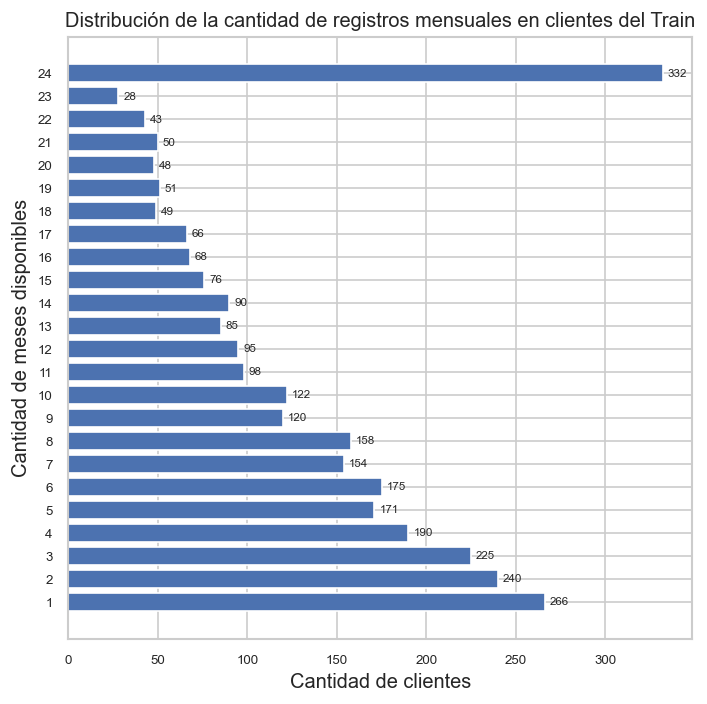

In [19]:
history = df_train.groupby('customer_id').size().value_counts().sort_index()

fig, ax = plt.subplots(1,1, figsize = (6, 6))
bar_label = ax.barh(
    history.index[::-1],
    history.values[::-1],
)
ax.bar_label(bar_label, fmt= '%d', padding= 3, fontsize =7)
ax.set_title('Distribución de la cantidad de registros mensuales en clientes del Train')
ax.set_ylabel('Cantidad de meses disponibles')
ax.set_xlabel('Cantidad de clientes')
ax.tick_params(axis= 'x', labelsize = 8)
ax.tick_params(axis= 'y', labelsize = 8)
ax.set_yticks(history.index[::-1]) 
plt.tight_layout()
fig.savefig(
    '../artifacts/feature_engineering/distribucion_registros_train.png',
    dpi = 300,
    bbox_inches = 'tight',
    facecolor = 'white'
)
plt.show()

## Features Temporales

### Lags

In [5]:
FEATS_W_LAG = [
    'usage_minutes',
    'support_calls',
    'complaints_last_3m',
    'late_payments',
    'marketing_emails_opened',
    'active_days_last_month'
]

LAGS = [1, 3, 6, 12]

for feat in FEATS_W_LAG:
    for lag in LAGS:
        tmp_feat = f'{feat}_lag_{lag}'
        df_train[tmp_feat] = df_train.groupby('customer_id')[feat].shift(lag)

### Ratios Temporales

- mean_3m
- mean_12
- max_12m
- min_12
- std_3m
- std_12m


Comportamiento reciente vs antiguo

In [6]:
## lag 1
FEAT_LAG_1 = [d+"_lag_1" for d in FEATS_W_LAG]
## Separar los otros lag
FEAT_LAG_3 = [d+"_lag_3" for d in FEATS_W_LAG]
FEAT_LAG_6 = [d+"_lag_6" for d in FEATS_W_LAG]
FEAT_LAG_12 = [d+"_lag_12" for d in FEATS_W_LAG]

# Solo para el lag_1
## mean_3m & mean_12m

exclude = FEAT_NUMERICALS+FEAT_CATEGORICALS+['customer_id']+[PERIOD]+[TARGET]+FEAT_LAG_3+FEAT_LAG_6+FEAT_LAG_12
WINDOWS = [3, 6, 12]
FEATS_OPERATIONS = [d for d in (df_train.columns.to_list()) if d not in exclude]

## mean_3m & mean_6 & mean_12m

new_features = {}

grouped = df_train.groupby('customer_id')

for feat in FEATS_OPERATIONS:
    g = grouped[feat]

    for windows in WINDOWS:
        var_tmp = f'{feat}_mean_{windows}'
        new_features[f'{feat}_mean_{windows}'] = (
        g
        .transform(
            lambda x: x.rolling(window= windows, min_periods= 1).mean()
        ))

## std_3m & std_6m & std_12m
for feat in FEATS_OPERATIONS:
    g = grouped[feat]
    for windows in WINDOWS:
        var_tmp = f'{feat}_std_{windows}'
        new_features[f'{feat}_std_{windows}'] = (
            g
            .transform(
                lambda x: x.rolling(window= windows, min_periods= 1).std()
            )
        ) 

### Se retira porque en acumulación ya se utiliza este mismo
# ## sum_3m & sum_6m & sum_12
# for feat in FEATS_OPERATIONS:
#     g = grouped[feat]
#     for windows in WINDOWS:
#         var_tmp = f'{feat}_sum_{windows}'
#         new_features[f'{feat}_sum_{windows}'] = (
#             g
#             .transform(
#                 lambda x: x.rolling(window= windows, min_periods= 1).sum()
#             )            
#         )


## Diferencias
for feat in FEATS_OPERATIONS:
    var_tmp = f'{feat}_diff_1'
    new_features[f'{feat}_diff'] = (
        df_train.groupby('customer_id')[feat].diff()
        )


## Rangos (Max - Min)
for feat in FEATS_OPERATIONS:
    g = grouped[feat]
    for windows in [6, 12]:
        var_tmp_max = f'{feat}_max_{windows}'
        var_tmp_min = f'{feat}_min_{windows}'
        var_tmp_range = f'{feat}_range_{windows}'
        new_features[f'{feat}_max_{windows}'] = (
            g
            .transform(
                lambda x: x.rolling(window= windows, min_periods = 1).max()
            )
        )
        new_features[f'{feat}_min_{windows}'] = (
            g
            .transform(
                lambda x: x.rolling(window= windows, min_periods = 1).min()
            )
        )
        new_features[f'{feat}_range_{windows}'] = new_features[f'{feat}_max_{windows}'] - new_features[f'{feat}_min_{windows}']

df_new_features = pd.DataFrame(new_features, index = df_train.index)
df_train = pd.concat([df_train, df_new_features], axis = 1)
df_train = df_train.copy()

In [7]:
## Features de recencia & frecuencia & acumulación
FEATS_RECENCIA_MAYOR_CERO = ['support_calls_lag_1', 'late_payments_lag_1', 'marketing_emails_opened_lag_1']
FEATS_RECENCIA_CONDICION = ['usage_minutes_lag_1', 'active_days_last_month_lag_1']


## Creando la feature de recencia

df_train["month_idx"] = (
    df_train["period"].dt.year * 12
    + df_train["period"].dt.month
)
new_features = {}

for feat in FEATS_RECENCIA_MAYOR_CERO:
    ##var_tmp = f'{feat}_lag_1_recencia'
    new_features[f'{feat}_boolean'] = df_train[feat] > 0
    
    # Creando índice mensual continuo

    new_features[f'{feat}_condicion'] = np.where(new_features[f'{feat}_boolean'], df_train['month_idx'], np.nan)
    new_features[f'{feat}_recencia'] = df_train['month_idx'] - ( pd.Series(new_features[f'{feat}_condicion'], index= df_train.index).groupby(df_train['customer_id']).ffill() )

    # Frecuencia & Acumulación / Severidad
    for windows in [6, 12]:

        new_features[f'{feat}_frec_{windows}'] = pd.Series(new_features[f'{feat}_boolean'], index= df_train.index).groupby(df_train['customer_id']).transform(
            lambda x: x.rolling(window= windows, min_periods= 1).sum()
        )

        # acumulación en un período de tiempo
        new_features[f'{feat}_sum_{windows}'] = (
            df_train.groupby('customer_id')[feat].transform(
                lambda x: x.rolling(window= windows, min_periods= 1).sum()
            )
        )

        ## acumulación histórica
        new_features[f'{feat}_cumsum'] = (
            df_train.groupby('customer_id')[feat].cumsum()
        )

df_new_features = pd.DataFrame(new_features, index = df_train.index)
df_train = pd.concat([df_train, df_new_features], axis = 1)
df_train = df_train.copy()

## Feature recencia de usage_minutes
df_train['usage_min_evento'] = df_train[FEATS_RECENCIA_CONDICION[0]] < 233
df_train['usage_severity'] = np.maximum(0, 233 - df_train['usage_minutes_lag_1'])
df_train['usage_min_condicion']= np.where(df_train['usage_min_evento'], df_train['month_idx'], np.nan)
df_train['usage_min_lag_1_recencia'] = df_train['month_idx'] - (df_train.groupby('customer_id')['usage_min_condicion'].ffill())
df_train['usage_min_lag_1_frecuencia_6m'] = (
    df_train.groupby('customer_id')['usage_min_evento'].transform(
        lambda x: x.rolling(window= 6, min_periods= 1).sum()
    )
)
df_train['usage_min_lag_1_frecuencia_12m'] = (
    df_train.groupby('customer_id')['usage_min_evento'].transform(
        lambda x: x.rolling(window= 12, min_periods= 1).sum()
    )
)

df_train['usage_severity_sum_3m'] = df_train.groupby('customer_id')['usage_severity'].transform(
    lambda x: x.rolling(window= 3, min_periods= 1).sum()
)
df_train['usage_severity_mean_3m'] = df_train.groupby('customer_id')['usage_severity'].transform(
    lambda x: x.rolling(window= 3, min_periods= 1).mean()
)
df_train['usage_severity_std_3m'] = df_train.groupby('customer_id')['usage_severity'].transform(
    lambda x: x.rolling(window= 3, min_periods= 1).std()
)

## Feature recencia de active_days_last_month_lag_1
df_train['active_days_last_month_evento'] = df_train[FEATS_RECENCIA_CONDICION[1]] < 23
df_train['active_days_last_month_condicion']= np.where(df_train['active_days_last_month_evento'], df_train['month_idx'], np.nan)
df_train['active_days_last_month_lag_1_recencia'] = df_train['month_idx'] - (df_train.groupby('customer_id')['active_days_last_month_condicion'].ffill())
df_train['active_days_last_month_severity'] = np.maximum(0, 23 - df_train['active_days_last_month_lag_1'])
df_train['active_days_last_month_freq_6m'] = (
    df_train.groupby('customer_id')['active_days_last_month_evento'].transform(
        lambda x: x.rolling(window= 6, min_periods= 1).sum()
    )
)
df_train['active_days_last_month_freq_12m'] = (
    df_train.groupby('customer_id')['active_days_last_month_evento'].transform(
        lambda x: x.rolling(window= 12, min_periods= 1).sum()
    )
)
df_train['active_days_last_month_severity_sum_3m'] = df_train.groupby('customer_id')['active_days_last_month_severity'].transform(
    lambda x: x.rolling(window= 3, min_periods= 1).sum()
)
df_train['active_days_last_month_severity_mean_3m'] = df_train.groupby('customer_id')['active_days_last_month_severity'].transform(
    lambda x: x.rolling(window= 3, min_periods= 1).mean()
)
df_train['active_days_last_month_severity_std_3m'] = df_train.groupby('customer_id')['active_days_last_month_severity'].transform(
    lambda x: x.rolling(window= 3, min_periods= 1).std()
)



In [8]:
new_features = {}

## Creación de Feature Cambios porcentuales
# pct_change
for feat in FEAT_LAG_1:
    new_features[f'{feat}_pct_change'] = (
        df_train.groupby('customer_id')[feat].pct_change()
    )

## Creación de Feature de Tendencia
# mean_3m vs mean_12m
for feat in FEAT_LAG_1:
    new_features[f'{feat}_trend_nom'] = (
        df_train[f'{feat}_mean_3'] - df_train[f'{feat}_mean_12'] 
    )

# ratio 
## ambos capturan bien la tendencia
for feat in FEAT_LAG_1:
    eps = 1e-5
    new_features[f'{feat}_trend_ratio'] = (
        (df_train[f'{feat}_mean_3'] / (df_train[f'{feat}_mean_12']+eps)) 
    )

## Creación de Deltas y Ratios (no se colocó aqui por redundancia) + slope
for feat in FEATS_W_LAG:
    new_features[f'{feat}_lag_1_3'] = df_train[f'{feat}_lag_1'] - df_train[f'{feat}_lag_3']
    new_features[f'{feat}_slope_1_6'] = (
        (df_train[f'{feat}_lag_1'] / df_train[f'{feat}_lag_6'])
    ) / 5


## Creación de Feature de consistencia
# std/mean
for feat in FEAT_LAG_1:
    new_features[f'{feat}_coefvar'] = (
        (df_train[f'{feat}_std_6'] / df_train[f'{feat}_mean_6'])
    )

## Creación de Features Calendario
df_train['month'] = df_train['period'].dt.month
df_train['month_sin'] = np.sin((2 * np.pi * df_train['month'])/12)
df_train['month_cos'] = np.cos((2 * np.pi * df_train['month'])/12)

df_new_features = pd.DataFrame(
    new_features,
    index= df_train.index
)
df_train = pd.concat([df_train, df_new_features], axis= 1)
df_train = df_train.copy()

## Feature de cobertura histórica
df_train['history_months'] = df_train.groupby('customer_id').cumcount()+1


In [9]:
## Columnas a DROPEAR antes de pasar a Training Model (Feature Selection)
DROP_ALWAYS = [
    'period',
    'customer_id',
    ##TARGET,
    'month',
    'month_idx'
]

DROP_INTERMEDIOS = [
    feat for feat in df_train.columns
    if feat.endswith('_max_6')
    or feat.endswith('_min_6') 
    or feat.endswith('_max_12')
    or feat.endswith('_min_12')
    or feat.endswith('_boolean')
    or feat.endswith('_condicion')
    or feat.endswith('_evento')
]

DROP_CURRENT_BEHAVIOUR =  [
    'usage_minutes',
    'support_calls',
    'complaints_last_3m',
    'late_payments',
    'marketing_emails_opened',
    'active_days_last_month'
]

cols_to_drop = list(set(
    DROP_ALWAYS
    + DROP_INTERMEDIOS
    + DROP_CURRENT_BEHAVIOUR
))

## Quitando las columnas seleccionadas
train_fe_full = df_train.drop(cols_to_drop, axis= 1, errors= 'ignore')
train_fe_full.to_parquet('../data/processed/train_fe_full.parquet') # incluye el target


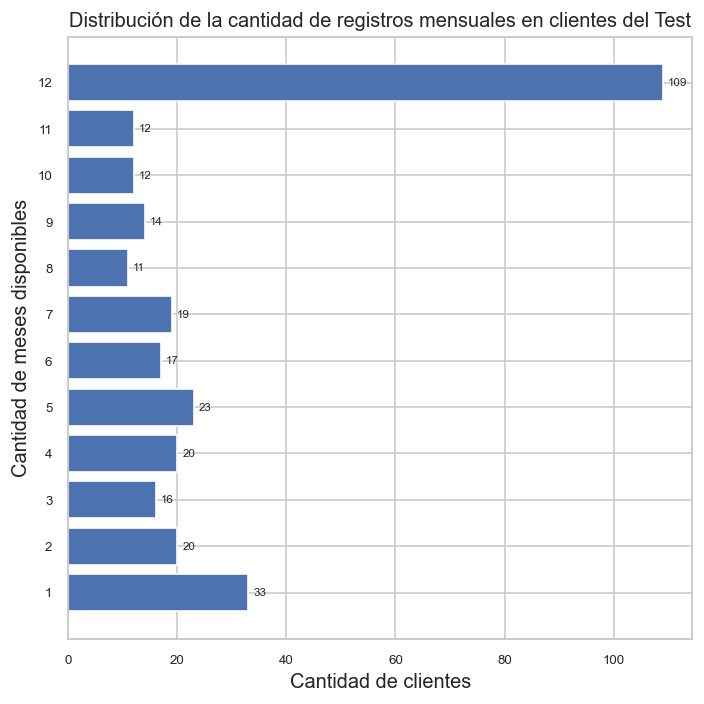

In [20]:
## Replicar Pipeline para Test
history = df_test.groupby('customer_id').size().value_counts().sort_index()

fig, ax = plt.subplots(1,1, figsize = (6, 6))
bar_label = ax.barh(
    history.index[::-1],
    history.values[::-1],
)
ax.bar_label(bar_label, fmt= '%d', padding= 3, fontsize =7)
ax.set_title('Distribución de la cantidad de registros mensuales en clientes del Test')
ax.set_ylabel('Cantidad de meses disponibles')
ax.set_xlabel('Cantidad de clientes')
ax.tick_params(axis= 'x', labelsize = 8)
ax.tick_params(axis= 'y', labelsize = 8)
ax.set_yticks(history.index[::-1]) 
plt.tight_layout()
fig.savefig(
    '../artifacts/feature_engineering/distribucion_registros_test.png',
    dpi = 300,
    bbox_inches = 'tight',
    facecolor = 'white'
)
plt.show()

In [13]:
## Pipeline completo de FE en Test

FEATS_W_LAG = [
    'usage_minutes',
    'support_calls',
    'complaints_last_3m',
    'late_payments',
    'marketing_emails_opened',
    'active_days_last_month'
]

LAGS = [1, 3, 6, 12]

for feat in FEATS_W_LAG:
    for lag in LAGS:
        tmp_feat = f'{feat}_lag_{lag}'
        df_test[tmp_feat] = df_test.groupby('customer_id')[feat].shift(lag)


## lag 1
FEAT_LAG_1 = [d+"_lag_1" for d in FEATS_W_LAG]
## Separar los otros lag
FEAT_LAG_3 = [d+"_lag_3" for d in FEATS_W_LAG]
FEAT_LAG_6 = [d+"_lag_6" for d in FEATS_W_LAG]
FEAT_LAG_12 = [d+"_lag_12" for d in FEATS_W_LAG]

# Solo para el lag_1
## mean_3m & mean_12m

exclude = FEAT_NUMERICALS+FEAT_CATEGORICALS+['customer_id']+[PERIOD]+[TARGET]+FEAT_LAG_3+FEAT_LAG_6+FEAT_LAG_12
WINDOWS = [3, 6, 12]
FEATS_OPERATIONS = [d for d in (df_test.columns.to_list()) if d not in exclude]

## mean_3m & mean_6 & mean_12m

new_features = {}

grouped = df_test.groupby('customer_id')

for feat in FEATS_OPERATIONS:
    g = grouped[feat]

    for windows in WINDOWS:
        var_tmp = f'{feat}_mean_{windows}'
        new_features[f'{feat}_mean_{windows}'] = (
        g
        .transform(
            lambda x: x.rolling(window= windows, min_periods= 1).mean()
        ))

## std_3m & std_6m & std_12m
for feat in FEATS_OPERATIONS:
    g = grouped[feat]
    for windows in WINDOWS:
        var_tmp = f'{feat}_std_{windows}'
        new_features[f'{feat}_std_{windows}'] = (
            g
            .transform(
                lambda x: x.rolling(window= windows, min_periods= 1).std()
            )
        ) 

### Se retira porque en acumulación ya se utiliza este mismo
# ## sum_3m & sum_6m & sum_12
# for feat in FEATS_OPERATIONS:
#     g = grouped[feat]
#     for windows in WINDOWS:
#         var_tmp = f'{feat}_sum_{windows}'
#         new_features[f'{feat}_sum_{windows}'] = (
#             g
#             .transform(
#                 lambda x: x.rolling(window= windows, min_periods= 1).sum()
#             )            
#         )


## Diferencias
for feat in FEATS_OPERATIONS:
    var_tmp = f'{feat}_diff_1'
    new_features[f'{feat}_diff'] = (
        df_test.groupby('customer_id')[feat].diff()
        )


## Rangos (Max - Min)
for feat in FEATS_OPERATIONS:
    g = grouped[feat]
    for windows in [6, 12]:
        var_tmp_max = f'{feat}_max_{windows}'
        var_tmp_min = f'{feat}_min_{windows}'
        var_tmp_range = f'{feat}_range_{windows}'
        new_features[f'{feat}_max_{windows}'] = (
            g
            .transform(
                lambda x: x.rolling(window= windows, min_periods = 1).max()
            )
        )
        new_features[f'{feat}_min_{windows}'] = (
            g
            .transform(
                lambda x: x.rolling(window= windows, min_periods = 1).min()
            )
        )
        new_features[f'{feat}_range_{windows}'] = new_features[f'{feat}_max_{windows}'] - new_features[f'{feat}_min_{windows}']

df_new_features = pd.DataFrame(new_features, index = df_test.index)
df_test = pd.concat([df_test, df_new_features], axis = 1)
df_test = df_test.copy()


## Features de recencia & frecuencia & acumulación
FEATS_RECENCIA_MAYOR_CERO = ['support_calls_lag_1', 'late_payments_lag_1', 'marketing_emails_opened_lag_1']
FEATS_RECENCIA_CONDICION = ['usage_minutes_lag_1', 'active_days_last_month_lag_1']


## Creando la feature de recencia

df_test["month_idx"] = (
    df_test["period"].dt.year * 12
    + df_test["period"].dt.month
)
new_features = {}

for feat in FEATS_RECENCIA_MAYOR_CERO:
    ##var_tmp = f'{feat}_lag_1_recencia'
    new_features[f'{feat}_boolean'] = df_test[feat] > 0
    
    # Creando índice mensual continuo

    new_features[f'{feat}_condicion'] = np.where(new_features[f'{feat}_boolean'], df_test['month_idx'], np.nan)
    new_features[f'{feat}_recencia'] = df_test['month_idx'] - ( pd.Series(new_features[f'{feat}_condicion'], index= df_test.index).groupby(df_test['customer_id']).ffill() )

    # Frecuencia & Acumulación / Severidad
    for windows in [6, 12]:

        new_features[f'{feat}_frec_{windows}'] = pd.Series(new_features[f'{feat}_boolean'], index= df_test.index).groupby(df_test['customer_id']).transform(
            lambda x: x.rolling(window= windows, min_periods= 1).sum()
        )

        # acumulación en un período de tiempo
        new_features[f'{feat}_sum_{windows}'] = (
            df_test.groupby('customer_id')[feat].transform(
                lambda x: x.rolling(window= windows, min_periods= 1).sum()
            )
        )

        ## acumulación histórica
        new_features[f'{feat}_cumsum'] = (
            df_test.groupby('customer_id')[feat].cumsum()
        )

df_new_features = pd.DataFrame(new_features, index = df_test.index)
df_test = pd.concat([df_test, df_new_features], axis = 1)
df_test = df_test.copy()

## Feature recencia de usage_minutes
df_test['usage_min_evento'] = df_test[FEATS_RECENCIA_CONDICION[0]] < 233
df_test['usage_severity'] = np.maximum(0, 233 - df_test['usage_minutes_lag_1'])
df_test['usage_min_condicion']= np.where(df_test['usage_min_evento'], df_test['month_idx'], np.nan)
df_test['usage_min_lag_1_recencia'] = df_test['month_idx'] - (df_test.groupby('customer_id')['usage_min_condicion'].ffill())
df_test['usage_min_lag_1_frecuencia_6m'] = (
    df_test.groupby('customer_id')['usage_min_evento'].transform(
        lambda x: x.rolling(window= 6, min_periods= 1).sum()
    )
)
df_test['usage_min_lag_1_frecuencia_12m'] = (
    df_test.groupby('customer_id')['usage_min_evento'].transform(
        lambda x: x.rolling(window= 12, min_periods= 1).sum()
    )
)

df_test['usage_severity_sum_3m'] = df_test.groupby('customer_id')['usage_severity'].transform(
    lambda x: x.rolling(window= 3, min_periods= 1).sum()
)
df_test['usage_severity_mean_3m'] = df_test.groupby('customer_id')['usage_severity'].transform(
    lambda x: x.rolling(window= 3, min_periods= 1).mean()
)
df_test['usage_severity_std_3m'] = df_test.groupby('customer_id')['usage_severity'].transform(
    lambda x: x.rolling(window= 3, min_periods= 1).std()
)

## Feature recencia de active_days_last_month_lag_1
df_test['active_days_last_month_evento'] = df_test[FEATS_RECENCIA_CONDICION[1]] < 23
df_test['active_days_last_month_condicion']= np.where(df_test['active_days_last_month_evento'], df_test['month_idx'], np.nan)
df_test['active_days_last_month_lag_1_recencia'] = df_test['month_idx'] - (df_test.groupby('customer_id')['active_days_last_month_condicion'].ffill())
df_test['active_days_last_month_severity'] = np.maximum(0, 23 - df_test['active_days_last_month_lag_1'])
df_test['active_days_last_month_freq_6m'] = (
    df_test.groupby('customer_id')['active_days_last_month_evento'].transform(
        lambda x: x.rolling(window= 6, min_periods= 1).sum()
    )
)
df_test['active_days_last_month_freq_12m'] = (
    df_test.groupby('customer_id')['active_days_last_month_evento'].transform(
        lambda x: x.rolling(window= 12, min_periods= 1).sum()
    )
)
df_test['active_days_last_month_severity_sum_3m'] = df_test.groupby('customer_id')['active_days_last_month_severity'].transform(
    lambda x: x.rolling(window= 3, min_periods= 1).sum()
)
df_test['active_days_last_month_severity_mean_3m'] = df_test.groupby('customer_id')['active_days_last_month_severity'].transform(
    lambda x: x.rolling(window= 3, min_periods= 1).mean()
)
df_test['active_days_last_month_severity_std_3m'] = df_test.groupby('customer_id')['active_days_last_month_severity'].transform(
    lambda x: x.rolling(window= 3, min_periods= 1).std()
)

new_features = {}

## Creación de Feature Cambios porcentuales
# pct_change
for feat in FEAT_LAG_1:
    new_features[f'{feat}_pct_change'] = (
        df_test.groupby('customer_id')[feat].pct_change()
    )

## Creación de Feature de Tendencia
# mean_3m vs mean_12m
for feat in FEAT_LAG_1:
    new_features[f'{feat}_trend_nom'] = (
        df_test[f'{feat}_mean_3'] - df_test[f'{feat}_mean_12'] 
    )

# ratio 
## ambos capturan bien la tendencia
for feat in FEAT_LAG_1:
    eps = 1e-5
    new_features[f'{feat}_trend_ratio'] = (
        (df_test[f'{feat}_mean_3'] / (df_test[f'{feat}_mean_12']+eps)) 
    )

## Creación de Deltas y Ratios (no se colocó aqui por redundancia) + slope
for feat in FEATS_W_LAG:
    new_features[f'{feat}_lag_1_3'] = df_test[f'{feat}_lag_1'] - df_test[f'{feat}_lag_3']
    new_features[f'{feat}_slope_1_6'] = (
        (df_test[f'{feat}_lag_1'] / df_test[f'{feat}_lag_6'])
    ) / 5


## Creación de Feature de consistencia
# std/mean
for feat in FEAT_LAG_1:
    new_features[f'{feat}_coefvar'] = (
        (df_test[f'{feat}_std_6'] / df_test[f'{feat}_mean_6'])
    )

## Creación de Features Calendario
df_test['month'] = df_test['period'].dt.month
df_test['month_sin'] = np.sin((2 * np.pi * df_test['month'])/12)
df_test['month_cos'] = np.cos((2 * np.pi * df_test['month'])/12)

df_new_features = pd.DataFrame(
    new_features,
    index= df_test.index
)
df_test = pd.concat([df_test, df_new_features], axis= 1)
df_test = df_test.copy()

## Feature de cobertura histórica
df_test['history_months'] = df_test.groupby('customer_id').cumcount()+1




In [14]:
## Columnas a DROPEAR antes de pasar a Training Model (Feature Selection)
DROP_ALWAYS = [
    'period',
    'customer_id',
    ##TARGET,
    'month',
    'month_idx'
]

DROP_INTERMEDIOS = [
    feat for feat in df_test.columns
    if feat.endswith('_max_6')
    or feat.endswith('_min_6') 
    or feat.endswith('_max_12')
    or feat.endswith('_min_12')
    or feat.endswith('_boolean')
    or feat.endswith('_condicion')
    or feat.endswith('_evento')
]

DROP_CURRENT_BEHAVIOUR =  [
    'usage_minutes',
    'support_calls',
    'complaints_last_3m',
    'late_payments',
    'marketing_emails_opened',
    'active_days_last_month'
]

cols_to_drop = list(set(
    DROP_ALWAYS
    + DROP_INTERMEDIOS
    + DROP_CURRENT_BEHAVIOUR
))

## Quitando las columnas seleccionadas
test_fe_full = df_test.drop(cols_to_drop, axis= 1, errors= 'ignore')
test_fe_full.to_parquet('../data/processed/test_fe_full.parquet') # incluye el target

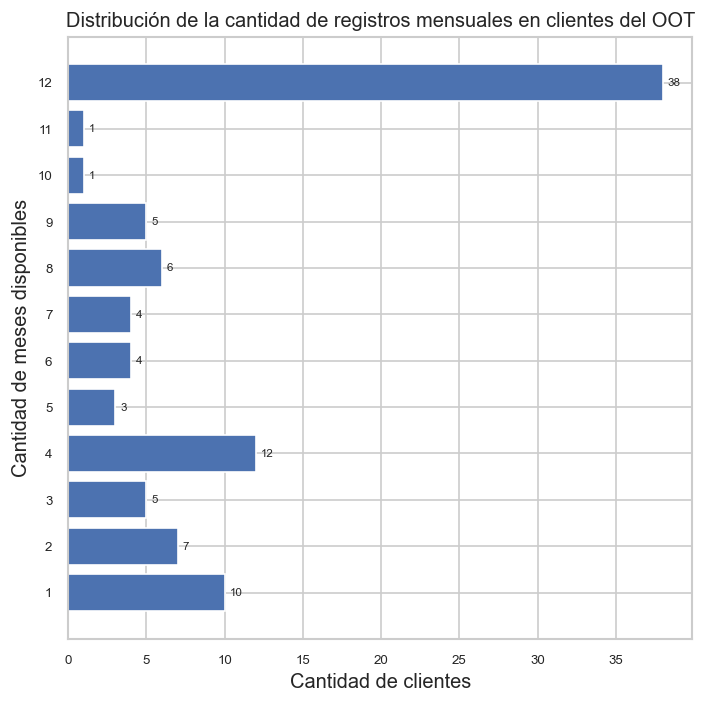

In [21]:
## Replicar Pipeline para OOT

history = df_oot.groupby('customer_id').size().value_counts().sort_index()

fig, ax = plt.subplots(1,1, figsize = (6, 6))
bar_label = ax.barh(
    history.index[::-1],
    history.values[::-1],
)
ax.bar_label(bar_label, fmt= '%d', padding= 3, fontsize =7)
ax.set_title('Distribución de la cantidad de registros mensuales en clientes del OOT')
ax.set_ylabel('Cantidad de meses disponibles')
ax.set_xlabel('Cantidad de clientes')
ax.tick_params(axis= 'x', labelsize = 8)
ax.tick_params(axis= 'y', labelsize = 8)
ax.set_yticks(history.index[::-1]) 
plt.tight_layout()
fig.savefig(
    '../artifacts/feature_engineering/distribucion_registros_oot.png',
    dpi = 300,
    bbox_inches = 'tight',
    facecolor = 'white'
)
plt.show()

In [16]:
## Pipeline completo de FE en OOT

FEATS_W_LAG = [
    'usage_minutes',
    'support_calls',
    'complaints_last_3m',
    'late_payments',
    'marketing_emails_opened',
    'active_days_last_month'
]

LAGS = [1, 3, 6, 12]

for feat in FEATS_W_LAG:
    for lag in LAGS:
        tmp_feat = f'{feat}_lag_{lag}'
        df_oot[tmp_feat] = df_oot.groupby('customer_id')[feat].shift(lag)


## lag 1
FEAT_LAG_1 = [d+"_lag_1" for d in FEATS_W_LAG]
## Separar los otros lag
FEAT_LAG_3 = [d+"_lag_3" for d in FEATS_W_LAG]
FEAT_LAG_6 = [d+"_lag_6" for d in FEATS_W_LAG]
FEAT_LAG_12 = [d+"_lag_12" for d in FEATS_W_LAG]

# Solo para el lag_1
## mean_3m & mean_12m

exclude = FEAT_NUMERICALS+FEAT_CATEGORICALS+['customer_id']+[PERIOD]+[TARGET]+FEAT_LAG_3+FEAT_LAG_6+FEAT_LAG_12
WINDOWS = [3, 6, 12]
FEATS_OPERATIONS = [d for d in (df_oot.columns.to_list()) if d not in exclude]

## mean_3m & mean_6 & mean_12m

new_features = {}

grouped = df_oot.groupby('customer_id')

for feat in FEATS_OPERATIONS:
    g = grouped[feat]

    for windows in WINDOWS:
        var_tmp = f'{feat}_mean_{windows}'
        new_features[f'{feat}_mean_{windows}'] = (
        g
        .transform(
            lambda x: x.rolling(window= windows, min_periods= 1).mean()
        ))

## std_3m & std_6m & std_12m
for feat in FEATS_OPERATIONS:
    g = grouped[feat]
    for windows in WINDOWS:
        var_tmp = f'{feat}_std_{windows}'
        new_features[f'{feat}_std_{windows}'] = (
            g
            .transform(
                lambda x: x.rolling(window= windows, min_periods= 1).std()
            )
        ) 

### Se retira porque en acumulación ya se utiliza este mismo
# ## sum_3m & sum_6m & sum_12
# for feat in FEATS_OPERATIONS:
#     g = grouped[feat]
#     for windows in WINDOWS:
#         var_tmp = f'{feat}_sum_{windows}'
#         new_features[f'{feat}_sum_{windows}'] = (
#             g
#             .transform(
#                 lambda x: x.rolling(window= windows, min_periods= 1).sum()
#             )            
#         )


## Diferencias
for feat in FEATS_OPERATIONS:
    var_tmp = f'{feat}_diff_1'
    new_features[f'{feat}_diff'] = (
        df_oot.groupby('customer_id')[feat].diff()
        )


## Rangos (Max - Min)
for feat in FEATS_OPERATIONS:
    g = grouped[feat]
    for windows in [6, 12]:
        var_tmp_max = f'{feat}_max_{windows}'
        var_tmp_min = f'{feat}_min_{windows}'
        var_tmp_range = f'{feat}_range_{windows}'
        new_features[f'{feat}_max_{windows}'] = (
            g
            .transform(
                lambda x: x.rolling(window= windows, min_periods = 1).max()
            )
        )
        new_features[f'{feat}_min_{windows}'] = (
            g
            .transform(
                lambda x: x.rolling(window= windows, min_periods = 1).min()
            )
        )
        new_features[f'{feat}_range_{windows}'] = new_features[f'{feat}_max_{windows}'] - new_features[f'{feat}_min_{windows}']

df_new_features = pd.DataFrame(new_features, index = df_oot.index)
df_oot = pd.concat([df_oot, df_new_features], axis = 1)
df_oot = df_oot.copy()


## Features de recencia & frecuencia & acumulación
FEATS_RECENCIA_MAYOR_CERO = ['support_calls_lag_1', 'late_payments_lag_1', 'marketing_emails_opened_lag_1']
FEATS_RECENCIA_CONDICION = ['usage_minutes_lag_1', 'active_days_last_month_lag_1']


## Creando la feature de recencia

df_oot["month_idx"] = (
    df_oot["period"].dt.year * 12
    + df_oot["period"].dt.month
)
new_features = {}

for feat in FEATS_RECENCIA_MAYOR_CERO:
    ##var_tmp = f'{feat}_lag_1_recencia'
    new_features[f'{feat}_boolean'] = df_oot[feat] > 0
    
    # Creando índice mensual continuo

    new_features[f'{feat}_condicion'] = np.where(new_features[f'{feat}_boolean'], df_oot['month_idx'], np.nan)
    new_features[f'{feat}_recencia'] = df_oot['month_idx'] - ( pd.Series(new_features[f'{feat}_condicion'], index= df_oot.index).groupby(df_oot['customer_id']).ffill() )

    # Frecuencia & Acumulación / Severidad
    for windows in [6, 12]:

        new_features[f'{feat}_frec_{windows}'] = pd.Series(new_features[f'{feat}_boolean'], index= df_oot.index).groupby(df_oot['customer_id']).transform(
            lambda x: x.rolling(window= windows, min_periods= 1).sum()
        )

        # acumulación en un período de tiempo
        new_features[f'{feat}_sum_{windows}'] = (
            df_oot.groupby('customer_id')[feat].transform(
                lambda x: x.rolling(window= windows, min_periods= 1).sum()
            )
        )

        ## acumulación histórica
        new_features[f'{feat}_cumsum'] = (
            df_oot.groupby('customer_id')[feat].cumsum()
        )

df_new_features = pd.DataFrame(new_features, index = df_oot.index)
df_oot = pd.concat([df_oot, df_new_features], axis = 1)
df_oot = df_oot.copy()

## Feature recencia de usage_minutes
df_oot['usage_min_evento'] = df_oot[FEATS_RECENCIA_CONDICION[0]] < 233
df_oot['usage_severity'] = np.maximum(0, 233 - df_oot['usage_minutes_lag_1'])
df_oot['usage_min_condicion']= np.where(df_oot['usage_min_evento'], df_oot['month_idx'], np.nan)
df_oot['usage_min_lag_1_recencia'] = df_oot['month_idx'] - (df_oot.groupby('customer_id')['usage_min_condicion'].ffill())
df_oot['usage_min_lag_1_frecuencia_6m'] = (
    df_oot.groupby('customer_id')['usage_min_evento'].transform(
        lambda x: x.rolling(window= 6, min_periods= 1).sum()
    )
)
df_oot['usage_min_lag_1_frecuencia_12m'] = (
    df_oot.groupby('customer_id')['usage_min_evento'].transform(
        lambda x: x.rolling(window= 12, min_periods= 1).sum()
    )
)

df_oot['usage_severity_sum_3m'] = df_oot.groupby('customer_id')['usage_severity'].transform(
    lambda x: x.rolling(window= 3, min_periods= 1).sum()
)
df_oot['usage_severity_mean_3m'] = df_oot.groupby('customer_id')['usage_severity'].transform(
    lambda x: x.rolling(window= 3, min_periods= 1).mean()
)
df_oot['usage_severity_std_3m'] = df_oot.groupby('customer_id')['usage_severity'].transform(
    lambda x: x.rolling(window= 3, min_periods= 1).std()
)

## Feature recencia de active_days_last_month_lag_1
df_oot['active_days_last_month_evento'] = df_oot[FEATS_RECENCIA_CONDICION[1]] < 23
df_oot['active_days_last_month_condicion']= np.where(df_oot['active_days_last_month_evento'], df_oot['month_idx'], np.nan)
df_oot['active_days_last_month_lag_1_recencia'] = df_oot['month_idx'] - (df_oot.groupby('customer_id')['active_days_last_month_condicion'].ffill())
df_oot['active_days_last_month_severity'] = np.maximum(0, 23 - df_oot['active_days_last_month_lag_1'])
df_oot['active_days_last_month_freq_6m'] = (
    df_oot.groupby('customer_id')['active_days_last_month_evento'].transform(
        lambda x: x.rolling(window= 6, min_periods= 1).sum()
    )
)
df_oot['active_days_last_month_freq_12m'] = (
    df_oot.groupby('customer_id')['active_days_last_month_evento'].transform(
        lambda x: x.rolling(window= 12, min_periods= 1).sum()
    )
)
df_oot['active_days_last_month_severity_sum_3m'] = df_oot.groupby('customer_id')['active_days_last_month_severity'].transform(
    lambda x: x.rolling(window= 3, min_periods= 1).sum()
)
df_oot['active_days_last_month_severity_mean_3m'] = df_oot.groupby('customer_id')['active_days_last_month_severity'].transform(
    lambda x: x.rolling(window= 3, min_periods= 1).mean()
)
df_oot['active_days_last_month_severity_std_3m'] = df_oot.groupby('customer_id')['active_days_last_month_severity'].transform(
    lambda x: x.rolling(window= 3, min_periods= 1).std()
)

new_features = {}

## Creación de Feature Cambios porcentuales
# pct_change
for feat in FEAT_LAG_1:
    new_features[f'{feat}_pct_change'] = (
        df_oot.groupby('customer_id')[feat].pct_change()
    )

## Creación de Feature de Tendencia
# mean_3m vs mean_12m
for feat in FEAT_LAG_1:
    new_features[f'{feat}_trend_nom'] = (
        df_oot[f'{feat}_mean_3'] - df_oot[f'{feat}_mean_12'] 
    )

# ratio 
## ambos capturan bien la tendencia
for feat in FEAT_LAG_1:
    eps = 1e-5
    new_features[f'{feat}_trend_ratio'] = (
        (df_oot[f'{feat}_mean_3'] / (df_oot[f'{feat}_mean_12']+eps)) 
    )

## Creación de Deltas y Ratios (no se colocó aqui por redundancia) + slope
for feat in FEATS_W_LAG:
    new_features[f'{feat}_lag_1_3'] = df_oot[f'{feat}_lag_1'] - df_oot[f'{feat}_lag_3']
    new_features[f'{feat}_slope_1_6'] = (
        (df_oot[f'{feat}_lag_1'] / df_oot[f'{feat}_lag_6'])
    ) / 5


## Creación de Feature de consistencia
# std/mean
for feat in FEAT_LAG_1:
    new_features[f'{feat}_coefvar'] = (
        (df_oot[f'{feat}_std_6'] / df_oot[f'{feat}_mean_6'])
    )

## Creación de Features Calendario
df_oot['month'] = df_oot['period'].dt.month
df_oot['month_sin'] = np.sin((2 * np.pi * df_oot['month'])/12)
df_oot['month_cos'] = np.cos((2 * np.pi * df_oot['month'])/12)

df_new_features = pd.DataFrame(
    new_features,
    index= df_oot.index
)
df_oot = pd.concat([df_oot, df_new_features], axis= 1)
df_oot = df_oot.copy()

## Feature de cobertura histórica
df_oot['history_months'] = df_oot.groupby('customer_id').cumcount()+1


In [17]:
## Columnas a DROPEAR antes de pasar a Training Model (Feature Selection)
DROP_ALWAYS = [
    'period',
    'customer_id',
    ##TARGET,
    'month',
    'month_idx'
]

DROP_INTERMEDIOS = [
    feat for feat in df_oot.columns
    if feat.endswith('_max_6')
    or feat.endswith('_min_6') 
    or feat.endswith('_max_12')
    or feat.endswith('_min_12')
    or feat.endswith('_boolean')
    or feat.endswith('_condicion')
    or feat.endswith('_evento')
]

DROP_CURRENT_BEHAVIOUR =  [
    'usage_minutes',
    'support_calls',
    'complaints_last_3m',
    'late_payments',
    'marketing_emails_opened',
    'active_days_last_month'
]

cols_to_drop = list(set(
    DROP_ALWAYS
    + DROP_INTERMEDIOS
    + DROP_CURRENT_BEHAVIOUR
))

## Quitando las columnas seleccionadas
oot_fe_full = df_oot.drop(cols_to_drop, axis= 1, errors= 'ignore')
oot_fe_full.to_parquet('../data/processed/oot_fe_full.parquet') # incluye el target

### Guardando el MLFLOW

In [18]:
dagshub.init(repo_owner='davidrodriguez2712', repo_name='proyecto-3-prediccion-churn', mlflow=True)
mlflow.set_tracking_uri(uri= MLFLOW['tracking_uri'])
mlflow.set_experiment(experiment_name= MLFLOW['experiment_name'])

Accessing as davidrodriguez2712

Initialized MLflow to track repo "davidrodriguez2712/proyecto-3-prediccion-churn"

Repository davidrodriguez2712/proyecto-3-prediccion-churn initialized!

<Experiment: artifact_location='mlflow-artifacts:/4eff3ac96700445fbbce571d47c1a5ac', creation_time=1781404772946, experiment_id='0', last_update_time=1781404772946, lifecycle_stage='active', name='Proyecto-3-prediccion-churn', tags={'mlflow.experimentKind': 'custom_model_development'}, trace_location=None, workspace='default'>

In [22]:
with mlflow.start_run(run_name= '02_feature_engineering') as run:
    mlflow.log_artifact(
        local_path= '../artifacts/feature_engineering/distribucion_registros_train.png',
        artifact_path= 'feature_engineering/figures'
    )
    mlflow.log_artifact(
        local_path= '../artifacts/feature_engineering/distribucion_registros_test.png',
        artifact_path= 'feature_engineering/figures'
    )
    mlflow.log_artifact(
        local_path= '../artifacts/feature_engineering/distribucion_registros_oot.png',
        artifact_path= 'feature_engineering/figures'
    )
    mlflow.log_artifact(
        local_path= '../data/processed/train_fe_full.parquet',
        artifact_path= 'feature_engineering/data_processed'
    )
    mlflow.log_artifact(
        local_path= '../data/processed/test_fe_full.parquet',
        artifact_path= 'feature_engineering/data_processed'
    )
    mlflow.log_artifact(
        local_path= '../data/processed/oot_fe_full.parquet',
        artifact_path= 'feature_engineering/data_processed'
    )

🏃 View run 02_feature_engineering at: https://dagshub.com/davidrodriguez2712/proyecto-3-prediccion-churn.mlflow/#/experiments/0/runs/d6682a207eb64d18ba9d137b54688abc
🧪 View experiment at: https://dagshub.com/davidrodriguez2712/proyecto-3-prediccion-churn.mlflow/#/experiments/0
